# 00 — MASTER REPORT: verifica unica di tutto il lavoro

Questo notebook richiama **ogni modulo del repo** e plotta tutto in un punto solo. Rieseguirlo = riconvalidare l'intero stack con dati freschi.

```bash
~/.venvs/quant/bin/python tools/build_master.py   # rigenera + riesegue
```

| Sezione | Modulo sorgente | Cosa valida |
|---|---|---|
| 1. Health check | `src/connectors/*` | i 4 connector rispondono |
| 2. Universe + quality | `market_data.py` | dati OHLCV puliti |
| 3. EDGAR + Polymarket | `edgar.py`, `polymarket.py` | filing SpaceX, probabilità live |
| 4. Correlazioni | `risk/metrics.py` | struttura vs regime |
| 5. Validazione distribuzionale | `research/dist_validation.py` | le fat tails del MC sono empiriche |
| 6. Lockup event study | `research/lockup_study.py` | la tesi di agosto sui precedenti storici |
| 7. Monte Carlo | `risk/montecarlo.py` | VaR/ES del piano + sensitività |
| 8. Verdetto | — | sintesi operativa |

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.viz import tufte_style, direct_label_lines, corr_heatmap, pnl_distribution, PALETTE
tufte_style()

## 1. Health check dei connector

Ogni fonte testata con una chiamata minima. FAIL qui = non fidarsi di nulla a valle.

In [2]:
import time
checks = []
def check(name, fn):
    t0 = time.time()
    try:
        out = fn(); checks.append({"connector": name, "status": "OK", "ms": int((time.time()-t0)*1000), "detail": out})
    except Exception as e:
        checks.append({"connector": name, "status": "FAIL", "ms": int((time.time()-t0)*1000), "detail": str(e)[:80]})

from src.connectors.market_data import get_ohlcv, get_universe
from src.connectors.edgar import recent_filings, form4_watch
from src.connectors.polymarket import search_markets
from src.connectors.fred import risk_free_rate

check("market_data (yfinance/stooq)", lambda: f"GOOGL ultimo close {get_ohlcv('GOOGL','6mo').Close.iloc[-1]:.2f}")
check("EDGAR (SEC ufficiale)", lambda: f"{len(recent_filings(limit=10))} filing SpaceX")
check("Polymarket Gamma", lambda: f"{len(search_markets('spacex'))} mercati live")
check("FRED (fallback ^IRX)", lambda: f"T-bill 3M {risk_free_rate():.2%}")
hc = pd.DataFrame(checks)
assert (hc.status == "OK").all(), f"CONNECTOR DOWN:\n{hc[hc.status!='OK']}"
hc

,connector,status,ms,detail
0,market_data (yfinance/stooq),OK,38,GOOGL ultimo close 363.31
1,EDGAR (SEC ufficiale),OK,257,10 filing SpaceX
2,Polymarket Gamma,OK,221,12 mercati live
3,FRED (fallback ^IRX),OK,30696,T-bill 3M 3.63%


## 2. Universe con quality report

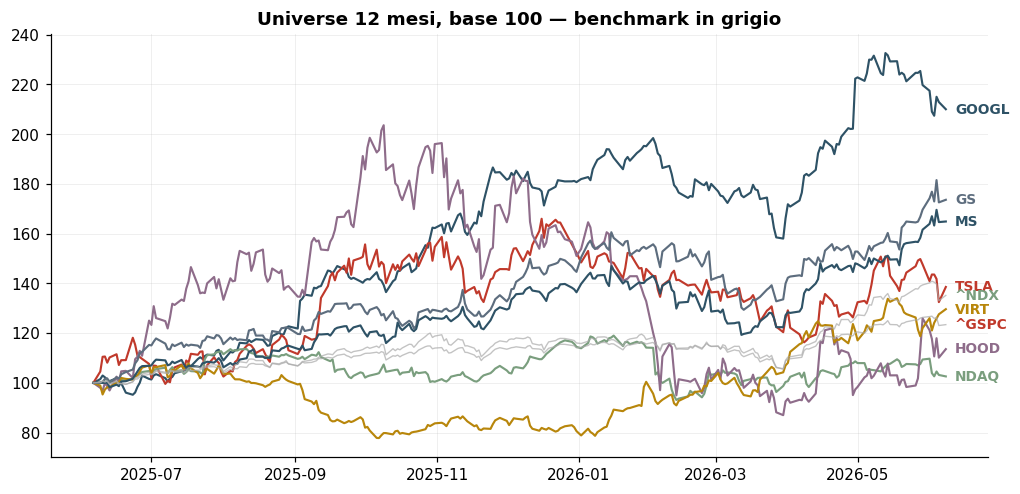

,rows,first,last,missing_bdays
ticker,,,,
GOOGL,500,2024-06-10,2026-06-08,21
TSLA,500,2024-06-10,2026-06-08,21
NDAQ,500,2024-06-10,2026-06-08,21
HOOD,500,2024-06-10,2026-06-08,21
VIRT,500,2024-06-10,2026-06-08,21
GS,500,2024-06-10,2026-06-08,21
MS,500,2024-06-10,2026-06-08,21
^GSPC,500,2024-06-10,2026-06-08,21
^NDX,500,2024-06-10,2026-06-08,21


In [3]:
UNIVERSE = ["GOOGL", "TSLA", "NDAQ", "HOOD", "VIRT", "GS", "MS", "^GSPC", "^NDX"]
prices, reports = get_universe(UNIVERSE, period="2y")
qa = pd.DataFrame(reports).set_index("ticker")
assert qa["issues"].map(len).sum() == 0, "QUALITY FAIL"
prices.to_parquet("../data/universe_prices.parquet")
norm = 100 * prices.dropna().tail(252) / prices.dropna().tail(252).iloc[0]
fig, ax = plt.subplots(figsize=(11, 5))
for c in norm.columns:
    b = c.startswith("^")
    ax.plot(norm.index, norm[c], lw=0.9 if b else 1.4, color="#AAAAAA" if b else None, alpha=0.7 if b else 1)
direct_label_lines(ax, norm)
ax.set_title("Universe 12 mesi, base 100 — benchmark in grigio")
plt.show()
qa[["rows", "first", "last", "missing_bdays"]]

## 3. SEC EDGAR + Polymarket live

Da agosto `form4_watch()` è il monitor delle vendite insider (obbligo di legge: pubbliche entro 2 giorni).

In [4]:
print(f"Form 3/4/144 SpaceX a oggi: {len(form4_watch())} (attesi da agosto, post-lockup)")
pd.DataFrame(recent_filings(limit=8))

Form 3/4/144 SpaceX a oggi: 0 (attesi da agosto, post-lockup)


,form,date,url
0,8-A12B,2026-06-10,https://www.sec.gov/Archives/edgar/data/118141...
1,8-A12B,2026-06-10,https://www.sec.gov/Archives/edgar/data/118141...
2,FWP,2026-06-09,https://www.sec.gov/Archives/edgar/data/118141...
3,FWP,2026-06-08,https://www.sec.gov/Archives/edgar/data/118141...
4,FWP,2026-06-05,https://www.sec.gov/Archives/edgar/data/118141...
5,FWP,2026-06-05,https://www.sec.gov/Archives/edgar/data/118141...
6,FWP,2026-06-04,https://www.sec.gov/Archives/edgar/data/118141...
7,FWP,2026-06-04,https://www.sec.gov/Archives/edgar/data/118141...


In [5]:
pm = pd.DataFrame([{"market": m["market"], **{f"P({k})": v for k, v in m["outcomes"].items()}, "volume_usd": int(m["volume"])} for m in search_markets("spacex", limit=8)])
pm

,market,P(Yes),P(No),volume_usd
0,SpaceX IPO closing market cap above $3T?,0.0650,0.9350,1825752
1,SpaceX IPO closing market cap above $2T?,0.6250,0.3750,1108071
2,SpaceX IPO closing market cap above $1.8T?,0.8050,0.1950,932944
3,Will SpaceX's market cap be between $2.5T and ...,0.1505,0.8495,911621
4,"Will SpaceX IPO by May 31, 2026?",0.0000,1.0000,906312
5,SpaceX IPO closing market cap above $2.4T?,0.2450,0.7550,871124
6,Will SpaceX's market cap be greater than $1T a...,0.9885,0.0115,744491
7,SpaceX IPO closing market cap above $1T?,0.9895,0.0105,736056


## 4. Correlazioni: struttura (2y) vs regime corrente (EWMA)

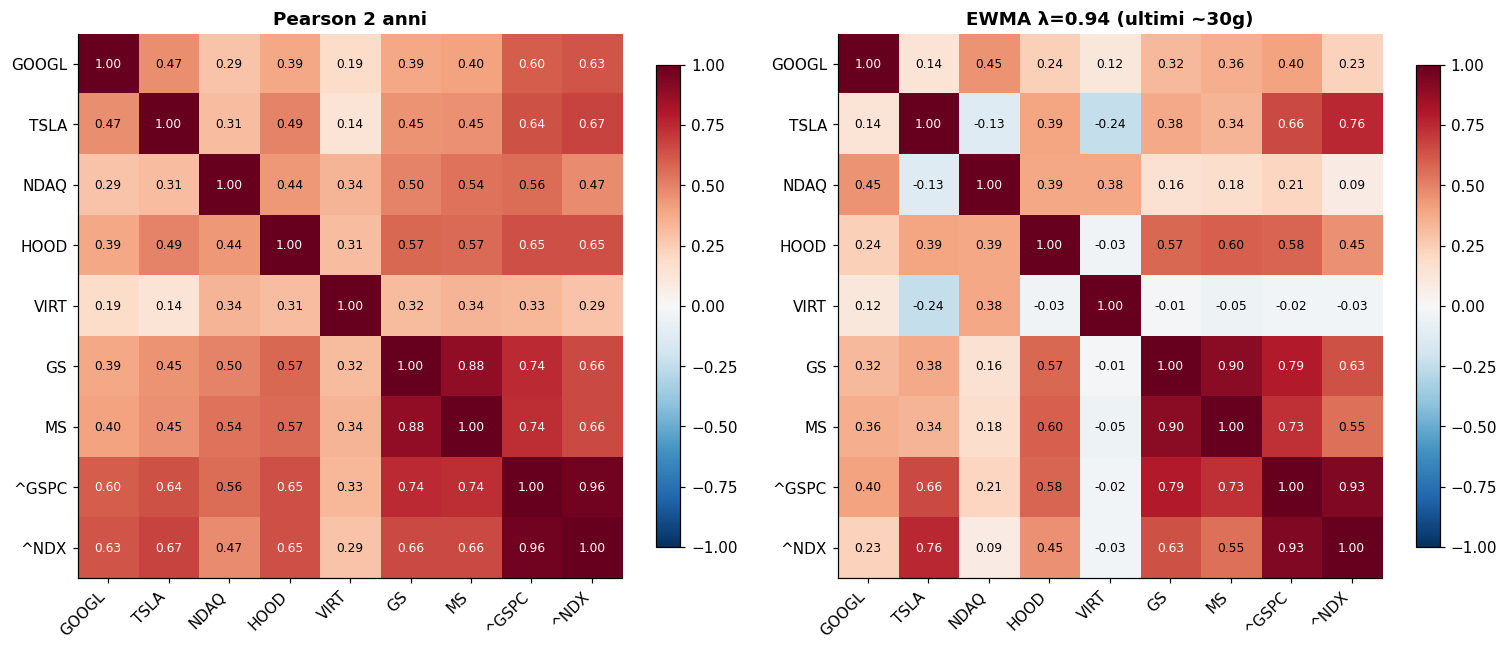

,vol_annua,beta_vs_SP500,max_drawdown,ret_tot_periodo
GOOGL,0.3048,1.1230,-0.2981,1.0919
TSLA,0.6067,2.3664,-0.5377,1.3531
NDAQ,0.2425,0.8245,-0.2176,0.5016
HOOD,0.7184,2.8454,-0.5726,2.6311
VIRT,0.3341,0.6745,-0.2783,1.2965
GS,0.3132,1.4238,-0.3090,1.3997
MS,0.3028,1.3731,-0.2924,1.3271
^GSPC,0.1639,1.0020,-0.1890,0.3815
^NDX,0.2165,1.2726,-0.2293,0.5421


In [6]:
from src.risk.metrics import log_returns, corr_matrix, ewma_corr, summary_table
rets = log_returns(prices.dropna())
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
corr_heatmap(axes[0], corr_matrix(rets), "Pearson 2 anni")
corr_heatmap(axes[1], ewma_corr(rets), "EWMA λ=0.94 (ultimi ~30g)")
fig.tight_layout(); plt.show()
summary_table(prices.dropna())

## 5. VALIDAZIONE VERTICALE — le fat tails sono nei dati?

Il MC assume Student-t con dof=4. Qui fittiamo la t sui rendimenti reali del proxy di volatilità (TSLA: stesso key-man risk di SPCX) e confrontiamo con la Normale. Se la Normale vincesse, il MC andrebbe rifatto.

TSLA: excess kurtosis 3.9 | t-dof fit 5.3 | loglik t 947 vs norm 921 → Student-t GIUSTIFICATA


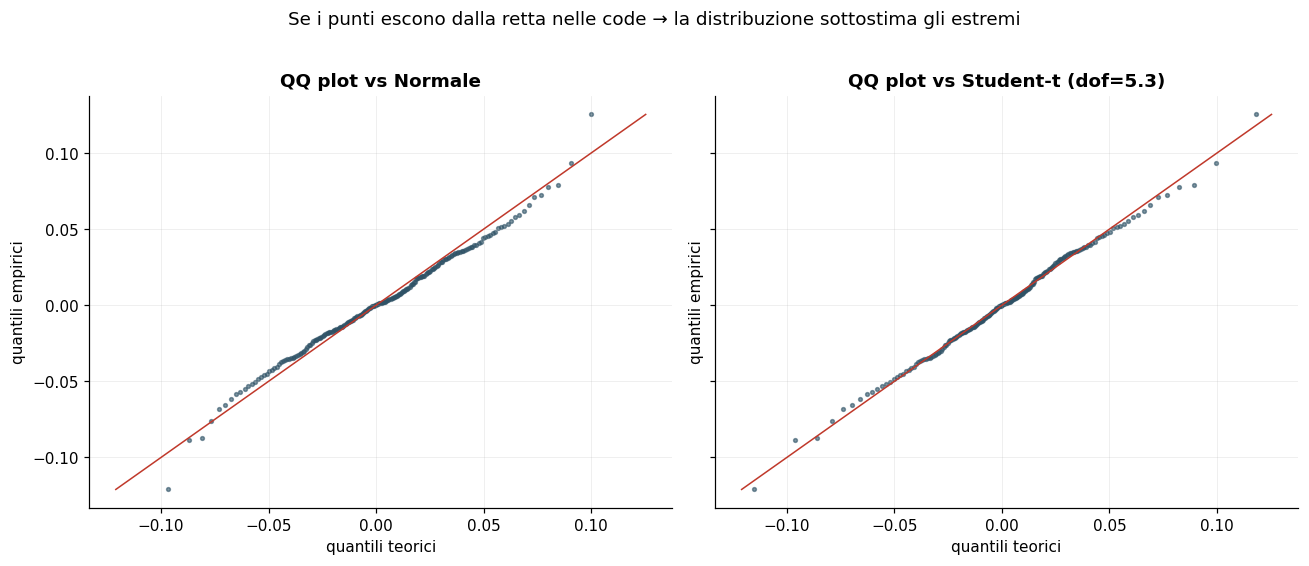

In [7]:
from scipy import stats
from src.research.dist_validation import fit_distributions, qq_data
f = fit_distributions("TSLA", "2y")
print(f"TSLA: excess kurtosis {f['excess_kurtosis']:.1f} | t-dof fit {f['t_dof']:.1f} | "
      f"loglik t {f['loglik_t']:.0f} vs norm {f['loglik_norm']:.0f} → {'Student-t GIUSTIFICATA' if f['t_wins'] else 'RIVEDERE MC'}")
r = f["returns"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (dist, params, name) in zip(axes, [(stats.norm, stats.norm.fit(r), "Normale"), (stats.t, stats.t.fit(r), f"Student-t (dof={f['t_dof']:.1f})")]):
    th, emp = qq_data(r, dist, *params)
    ax.scatter(th, emp, s=6, alpha=0.6)
    lim = [min(th.min(), emp.min()), max(th.max(), emp.max())]
    ax.plot(lim, lim, color=PALETTE[1], lw=1)
    ax.set_title(f"QQ plot vs {name}")
    ax.set_xlabel("quantili teorici"); ax.set_ylabel("quantili empirici")
fig.suptitle("Se i punti escono dalla retta nelle code → la distribuzione sottostima gli estremi", y=1.02)
fig.tight_layout(); plt.show()

## 6. VALIDAZIONE ORIZZONTALE — event study sui lockup storici

UBER (nov 2019), RIVN (mag 2022), META (nov 2012), SNAP (lug 2017): prezzo normalizzato a 100 alla scadenza lockup (T0), da T-30 a T+60 sedute.

**Scoperta che corregge la tesi naive**: il calo medio avviene PRIMA della scadenza (anticipazione), e T0 è spesso un minimo locale. Si vende il rumor, si compra la news.

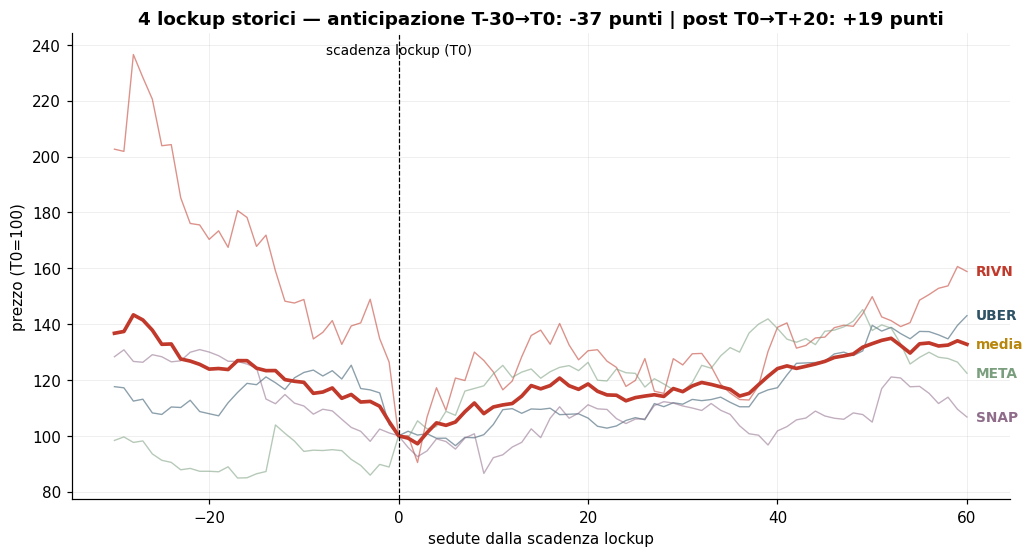

,UBER,RIVN,META,SNAP,media
-30,117.6,202.6,98.3,128.3,136.7
-20,107.9,170.3,87.3,130.0,123.9
-10,122.7,148.8,94.4,110.7,119.1
0,100.0,100.0,100.0,100.0,100.0
10,104.0,122.9,122.2,92.2,110.3
20,106.3,130.5,126.3,111.1,118.6
40,117.2,138.8,138.4,101.8,124.1
60,143.0,158.8,122.4,106.7,132.7


In [8]:
from src.research.lockup_study import lockup_panel, LOCKUP_EVENTS
panel = lockup_panel()
fig, ax = plt.subplots(figsize=(11, 5.5))
for c in [c for c in panel.columns if c != "media"]:
    ax.plot(panel.index, panel[c], lw=0.9, alpha=0.55)
ax.plot(panel.index, panel["media"], lw=2.4, color=PALETTE[1])
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.annotate("scadenza lockup (T0)", (0, ax.get_ylim()[1]*0.97), fontsize=9, ha="center")
direct_label_lines(ax, panel)
ant = panel["media"].loc[0] - panel["media"].loc[-30]
post = panel["media"].loc[20] - panel["media"].loc[0]
ax.set_title(f"4 lockup storici — anticipazione T-30→T0: {ant:+.0f} punti | post T0→T+20: {post:+.0f} punti")
ax.set_xlabel("sedute dalla scadenza lockup"); ax.set_ylabel("prezzo (T0=100)")
plt.show()
panel.loc[[-30, -20, -10, 0, 10, 20, 40, 60]].round(1)

**Implicazione operativa (recepita nel cronoprogramma)**: lo spread va aperto a luglio (già previsto) e chiuso A RIDOSSO dello sblocco insider — entro T+5, senza aspettare una continuazione del calo che storicamente non arriva. Caveat: qui T0 è la scadenza lockup classica a 180g; SPCX ha uno sblocco scaglionato e anticipato, il pattern può spostarsi in avanti (l'anticipazione potrebbe iniziare a luglio).

## 7. Monte Carlo del piano + sensitività

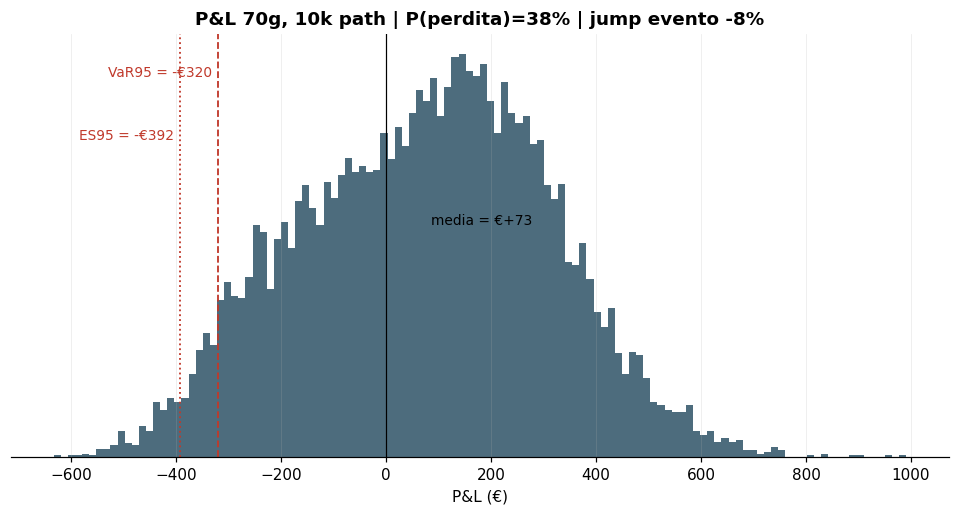

,P&L medio €,P(perdita),ES95 €
jump,,,
-20%,127,28%,347
-15%,102,32%,367
-10%,78,37%,385
-8%,68,39%,393
-5%,53,42%,401
+0%,31,45%,414
+5%,9,50%,425


In [9]:
from src.risk.montecarlo import McConfig, SpreadPosition, simulate, report
from dataclasses import replace
cfg, spread = McConfig(), SpreadPosition()
res = simulate(cfg, spread)
rep = report(res)
assert res["pnl_spread_eur"].min() >= -(spread.debit*100*spread.contracts/1.08) - 1e-6, "HARD CAP VIOLATO"
fig, ax = plt.subplots(figsize=(11, 5))
pnl_distribution(ax, res["pnl_total_eur"], rep["VaR95"], rep["ES95"],
                 f"P&L 70g, 10k path | P(perdita)={rep['p_loss']:.0%} | jump evento {cfg.jump_mean:+.0%}")
plt.show()
rows = []
for jm in [-0.20, -0.15, -0.10, -0.08, -0.05, 0.0, 0.05]:
    r2 = report(simulate(replace(cfg, jump_mean=jm, seed=11), spread))
    rows.append({"jump": f"{jm:+.0%}", "P&L medio €": round(r2["mean"]), "P(perdita)": f"{r2['p_loss']:.0%}", "ES95 €": round(r2["ES95"])})
pd.DataFrame(rows).set_index("jump")

## 8. Verdetto del master report

1. **Pipeline**: 4/4 connector vivi, quality report pulito su 9 ticker (sezioni 1-2).
2. **Modello validato**: fat tails empiriche (kurtosis ~4, t-dof ~5) → la Student-t del MC è giustificata dai dati, non un vezzo (sezione 5).
3. **Tesi raffinata dall'event study**: il calo da lockup è da ANTICIPAZIONE (media -37 punti T-30→T0 sui 4 precedenti); la scadenza è spesso un minimo locale. Regola d'uscita: chiudere lo spread entro T+5 dallo sblocco (sezione 6).
4. **Rischio del piano**: hard cap dello spread verificato su ogni path; la coda sinistra è tutta GOOGL/beta (sezione 7).
5. **Da aggiornare post-IPO** (~22 giu): `spcx_s0`, `spcx_vol` dalla IV reale, `debit` reale in `McConfig`/`SpreadPosition`; da agosto monitorare `form4_watch()`.

Capitale: €2.000 | perdita max strutturale ~20% | EV ≈ 0: il piano compra processo e apprendimento, non rendimento atteso.